# Generating Sanskrit (Devanagari) Characters using Diffusion Models
### Generative AI Fundamentals -- Assignment

**Language:** Sanskrit (Devanagari) | **Model:** DDPM (UNet2D) | **Framework:** PyTorch + Diffusers

Pipeline: Unicode Block -> PIL Rendering -> PNG Dataset -> GlyphDataset -> UNet2D DDPM -> Training -> Generation

> Runs on Windows, Mac, and Google Colab -- no wget, no version conflicts

## Cell 1: Install Dependencies

In [1]:
# Cell 1: Install dependencies
# diffusers >= 0.30.0 removes the broken cached_download; works with latest huggingface_hub

import sys
!{sys.executable} -m pip install -q "diffusers>=0.30.0" "accelerate>=1.0.0" "transformers>=4.40.0"
!{sys.executable} -m pip install -q Pillow tqdm matplotlib

# Cross-platform font download (urllib -- works on Windows, no wget needed)
import urllib.request, os, pathlib

FONT_URL  = "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansDevanagari/NotoSansDevanagari-Regular.ttf"
FONT_PATH = "NotoSansDevanagari-Regular.ttf"

if not pathlib.Path(FONT_PATH).exists():
    print("Downloading Noto Sans Devanagari font...", end=" ")
    urllib.request.urlretrieve(FONT_URL, FONT_PATH)
    print("done")
else:
    print("Font already present")


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Font already present



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cell 2: Import Libraries

In [2]:
# Cell 2: Imports
import os, json, warnings
from pathlib import Path
from dataclasses import dataclass

import torch
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from diffusers import (
    UNet2DModel,
    DDPMScheduler,
    DPMSolverMultistepScheduler,
    DDPMPipeline,
)
from diffusers.optimization import get_cosine_schedule_with_warmup
from accelerate import Accelerator

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

import diffusers, accelerate
print(f"diffusers  : {diffusers.__version__}")
print(f"accelerate : {accelerate.__version__}")
print(f"torch      : {torch.__version__}")
print(f"device     : {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else " (CPU)"))


c:\Users\LOQ\Desktop\Vizuara\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


diffusers  : 0.37.1
accelerate : 1.13.0
torch      : 2.7.1+cu118
device     : cuda (NVIDIA GeForce RTX 3050 6GB Laptop GPU)


## Cell 3: Build the Dataset

Renders every valid glyph in the Devanagari Unicode block U+0900 to U+097F (128 code points) as 64x64 PNG.
Glyphs that map to the replacement character are skipped. No manual download required.

Saved   : 128 glyphs -> data_devanagari/
Skipped : 0 unsupported code points


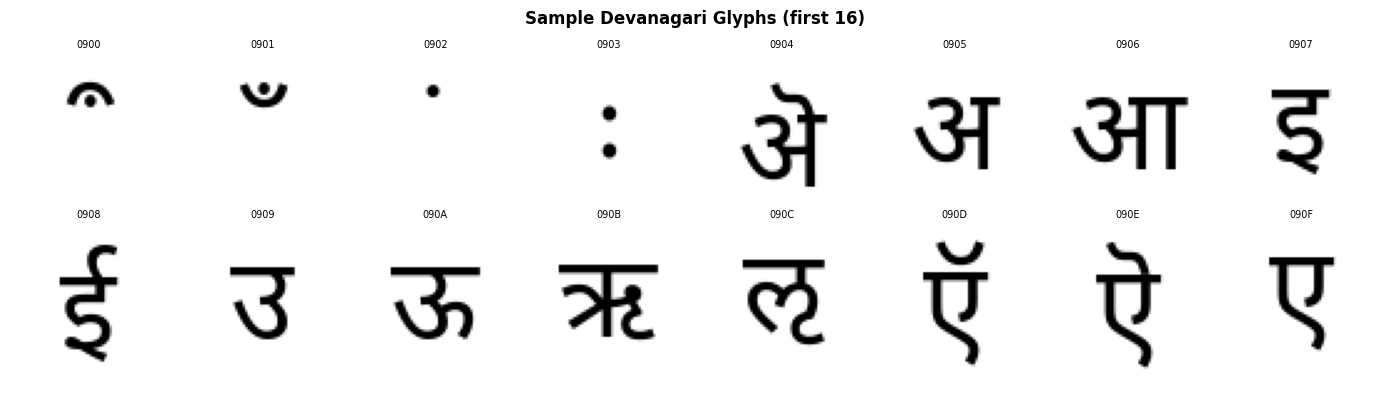

In [3]:
# Cell 3: Generate Devanagari PNG dataset

FONT_PATH  = "NotoSansDevanagari-Regular.ttf"
DATA_DIR   = "data_devanagari"
IMAGE_SIZE = 64
FONT_SIZE  = 46

os.makedirs(DATA_DIR, exist_ok=True)
font = ImageFont.truetype(FONT_PATH, FONT_SIZE)

def render_glyph(char, size=IMAGE_SIZE):
    img  = Image.new("L", (size, size), 255)
    draw = ImageDraw.Draw(img)
    bb   = draw.textbbox((0, 0), char, font=font)
    w, h = bb[2] - bb[0], bb[3] - bb[1]
    x    = (size - w) / 2 - bb[0]
    y    = (size - h) / 2 - bb[1]
    draw.text((x, y), char, fill=0, font=font)
    return img

def is_supported(char):
    repl     = chr(0xFFFD)
    img_char = render_glyph(char)
    img_repl = render_glyph(repl)
    pixels   = list(img_char.getdata())
    all_white = all(p > 250 for p in pixels)
    return (img_char.tobytes() != img_repl.tobytes()) and not all_white

saved, skipped = 0, 0
metadata = []

for cp in range(0x0900, 0x0980):
    char = chr(cp)
    if is_supported(char):
        img   = render_glyph(char)
        fname = f"{cp:04X}.png"
        img.save(os.path.join(DATA_DIR, fname))
        metadata.append({"file_name": fname, "unicode": f"U+{cp:04X}", "char": char})
        saved += 1
    else:
        skipped += 1

with open(os.path.join(DATA_DIR, "metadata.jsonl"), "w", encoding="utf-8") as f:
    for entry in metadata:
        f.write(json.dumps(entry, ensure_ascii=False) + "")

print(f"Saved   : {saved} glyphs -> {DATA_DIR}/")
print(f"Skipped : {skipped} unsupported code points")

# Preview first 16 glyphs
sample_files = sorted(Path(DATA_DIR).glob("*.png"))[:16]
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for ax, fp in zip(axes.flat, sample_files):
    ax.imshow(Image.open(fp), cmap="gray", vmin=0, vmax=255)
    ax.set_title(fp.stem, fontsize=7)
    ax.axis("off")
for ax in axes.flat[len(sample_files):]:
    ax.axis("off")
plt.suptitle("Sample Devanagari Glyphs (first 16)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## Cell 4: Preprocessing -- Augmentation + DataLoader

Devanagari has ~90 usable glyphs. Augmentation expands this to ~810.

In [4]:
# Cell 4a: Augment dataset (90 -> ~810 images)

import random, shutil

AUG_DIR     = "data_devanagari_aug"
AUG_PER_IMG = 9

os.makedirs(AUG_DIR, exist_ok=True)
source_paths = sorted(Path(DATA_DIR).glob("*.png"))

for src in source_paths:
    img = Image.open(src).convert("L")
    shutil.copy(str(src), os.path.join(AUG_DIR, src.name))  # keep original

    for i in range(AUG_PER_IMG):
        aug = img.copy()

        # Random rotation
        angle = random.uniform(-8, 8)
        aug   = aug.rotate(angle, resample=Image.BICUBIC, fillcolor=255)

        # Random scale
        scale = random.uniform(0.88, 1.12)
        new_w = max(1, int(aug.width  * scale))
        new_h = max(1, int(aug.height * scale))
        aug   = aug.resize((new_w, new_h), Image.LANCZOS)

        # Pad or crop back to IMAGE_SIZE
        canvas  = Image.new("L", (IMAGE_SIZE, IMAGE_SIZE), 255)
        paste_x = max(0, (IMAGE_SIZE - aug.width)  // 2)
        paste_y = max(0, (IMAGE_SIZE - aug.height) // 2)
        crop_x  = max(0, (aug.width  - IMAGE_SIZE) // 2)
        crop_y  = max(0, (aug.height - IMAGE_SIZE) // 2)
        aug     = aug.crop((crop_x, crop_y,
                            crop_x + min(aug.width,  IMAGE_SIZE),
                            crop_y + min(aug.height, IMAGE_SIZE)))
        canvas.paste(aug, (paste_x, paste_y))
        canvas.save(os.path.join(AUG_DIR, f"{src.stem}_aug{i:02d}.png"))

total = len(list(Path(AUG_DIR).glob("*.png")))
print(f"Augmented dataset: {total} images in {AUG_DIR}/")


Augmented dataset: 1280 images in data_devanagari_aug/


In [21]:
# Cell 4b: Training configuration

@dataclass
class TrainingConfig:
    image_size                  = 64
    train_batch_size            = 16      # lower to 8 if out-of-memory
    eval_batch_size             = 16
    num_epochs                  = 100     # increase to 200 for better quality
    gradient_accumulation_steps = 1
    learning_rate               = 1e-4
    lr_warmup_steps             = 200
    save_image_epochs           = 10
    save_model_epochs           = 50
    mixed_precision             = "fp16" if DEVICE == "cuda" else "no"
    output_dir                  = "ddpm-devanagari"
    seed                        = 42

config = TrainingConfig()
print(f"Config ready | epochs={config.num_epochs} | batch={config.train_batch_size} | precision={config.mixed_precision}")


Config ready | epochs=100 | batch=16 | precision=fp16


In [22]:
# Cell 4c: Dataset class + DataLoader

def to_neg1_1(img):
    return img * 2.0 - 1.0   # scale [0,1] -> [-1,1] as required by DDPM

class GlyphDataset(Dataset):
    def __init__(self, folder, image_size):
        self.paths = sorted(Path(folder).glob("*.png"))
        if not self.paths:
            raise FileNotFoundError(f"No PNG files found in {folder!r}")
        self.transform = T.Compose([
            T.Resize((image_size, image_size)),
            T.ToTensor(),
            T.Lambda(to_neg1_1),
        ])
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("L")
        return self.transform(img)

dataset          = GlyphDataset(AUG_DIR, image_size=config.image_size)
train_dataloader = DataLoader(
    dataset,
    batch_size  = config.train_batch_size,
    shuffle     = True,
    num_workers = 0,          # 0 avoids Windows multiprocessing spawn errors
    pin_memory  = (DEVICE == "cuda"),
)

sample = next(iter(train_dataloader))
print(f"Dataset size   : {len(dataset)} images")
print(f"Batches/epoch  : {len(train_dataloader)}")
print(f"Batch shape    : {sample.shape}  (B, C, H, W)")
print(f"Value range    : [{sample.min():.2f}, {sample.max():.2f}]  (should be -1 to 1)")


Dataset size   : 1280 images
Batches/epoch  : 80
Batch shape    : torch.Size([16, 1, 64, 64])  (B, C, H, W)
Value range    : [-1.00, 1.00]  (should be -1 to 1)


## Cell 5: Model Definition -- UNet2D (DDPM)

**Why DDPM?** Simple MSE loss on predicted noise -- stable training even on small datasets.
Self-attention at the bottleneck lets the model learn global stroke structure.

In [23]:
# Cell 5: UNet2D model

model = UNet2DModel(
    sample_size        = config.image_size,
    in_channels        = 1,       # greyscale
    out_channels       = 1,
    layers_per_block   = 2,
    block_out_channels = (64, 128, 256, 256),
    down_block_types   = (
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",   # self-attention at bottleneck
        "DownBlock2D",
    ),
    up_block_types     = (
        "UpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"UNet2D on {DEVICE}")
print(f"Parameters : {total_params:.2f} M")
print(f"I/O shape  : (B, 1, {config.image_size}, {config.image_size})")


UNet2D on cuda
Parameters : 25.30 M
I/O shape  : (B, 1, 64, 64)


## Cell 6: Training Loop

- Training scheduler: DDPMScheduler (1000 timesteps, squaredcos_cap_v2)
- Inference scheduler: DPMSolverMultistepScheduler (50 steps, 20x faster)
- Optimizer: AdamW + cosine warmup
- Direct training call (no notebook_launcher -- Windows compatible)

In [24]:
# Cell 6a: Schedulers and optimiser

noise_scheduler     = DDPMScheduler(num_train_timesteps=1000, beta_schedule="squaredcos_cap_v2")
inference_scheduler = DPMSolverMultistepScheduler()

optimizer    = AdamW(model.parameters(), lr=config.learning_rate)
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer          = optimizer,
    num_warmup_steps   = config.lr_warmup_steps,
    num_training_steps = len(train_dataloader) * config.num_epochs,
)
print("Schedulers and optimiser ready")
print(f"Beta schedule : squaredcos_cap_v2")
print(f"Total steps   : {len(train_dataloader) * config.num_epochs}")


Schedulers and optimiser ready
Beta schedule : squaredcos_cap_v2
Total steps   : 8000


In [25]:
# Cell 6b: Helper functions for grid and evaluation

def make_grid(images, rows, cols):
    w, h = images[0].size
    grid = Image.new("RGB", (cols * w, rows * h), (255, 255, 255))
    for i, img in enumerate(images):
        grid.paste(img, box=(i % cols * w, i // cols * h))
    return grid

def evaluate_and_save(config, epoch_label, pipeline):
    with torch.no_grad():
        images = pipeline(
            batch_size          = 16,
            generator           = torch.Generator(device="cpu").manual_seed(config.seed),
            num_inference_steps = 50,
        ).images
    grid    = make_grid(images, rows=4, cols=4)
    out_dir = os.path.join(config.output_dir, "samples")
    os.makedirs(out_dir, exist_ok=True)
    path    = os.path.join(out_dir, f"epoch_{epoch_label:04d}.png")
    grid.save(path)
    plt.figure(figsize=(6, 6))
    plt.imshow(grid, cmap="gray")
    plt.title(f"Epoch {epoch_label} samples", fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    return path

print("Helper functions ready")


Helper functions ready


Training for 100 epochs on cuda...
Mixed precision : fp16
Batches/epoch   : 80


  Epoch 001 | avg loss: 0.46647


  Epoch 002 | avg loss: 0.06514


  Epoch 003 | avg loss: 0.04209


  Epoch 004 | avg loss: 0.03077


...

  Epoch 007 | avg loss: 0.02250


  Epoch 008 | avg loss: 0.01969


  Epoch 009 | avg loss: 0.02092


  Epoch 010 | avg loss: 0.01915


100%|██████████| 50/50 [00:06<00:00,  8.12it/s]


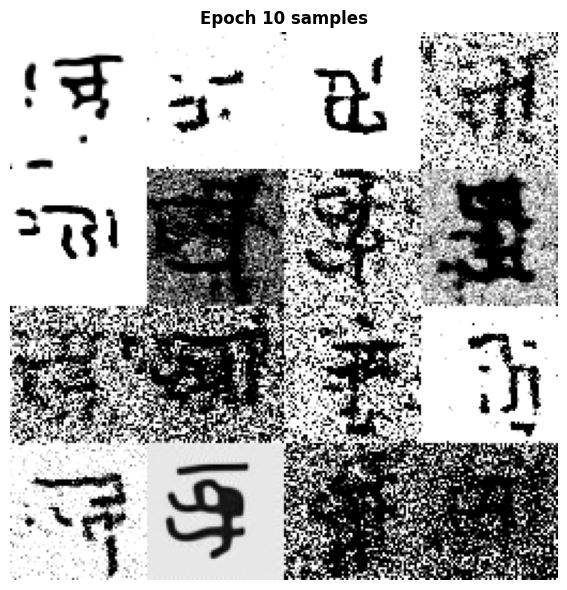

   Saved sample grid -> ddpm-devanagari\samples\epoch_0010.png


  Epoch 011 | avg loss: 0.01802


  Epoch 012 | avg loss: 0.01647


  Epoch 013 | avg loss: 0.01633


  Epoch 014 | avg loss: 0.01610


...

  Epoch 017 | avg loss: 0.01557


  Epoch 018 | avg loss: 0.01415


  Epoch 019 | avg loss: 0.01436


  Epoch 020 | avg loss: 0.01389


100%|██████████| 50/50 [00:03<00:00, 14.88it/s]


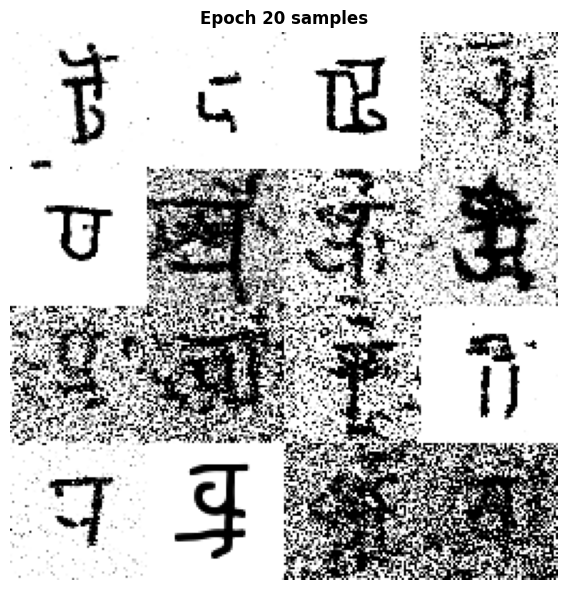

   Saved sample grid -> ddpm-devanagari\samples\epoch_0020.png


  Epoch 021 | avg loss: 0.01474


  Epoch 022 | avg loss: 0.01345


  Epoch 023 | avg loss: 0.01306


  Epoch 024 | avg loss: 0.01315


...

  Epoch 027 | avg loss: 0.01250


  Epoch 028 | avg loss: 0.01270


  Epoch 029 | avg loss: 0.01169


  Epoch 030 | avg loss: 0.01355


100%|██████████| 50/50 [00:03<00:00, 14.40it/s]


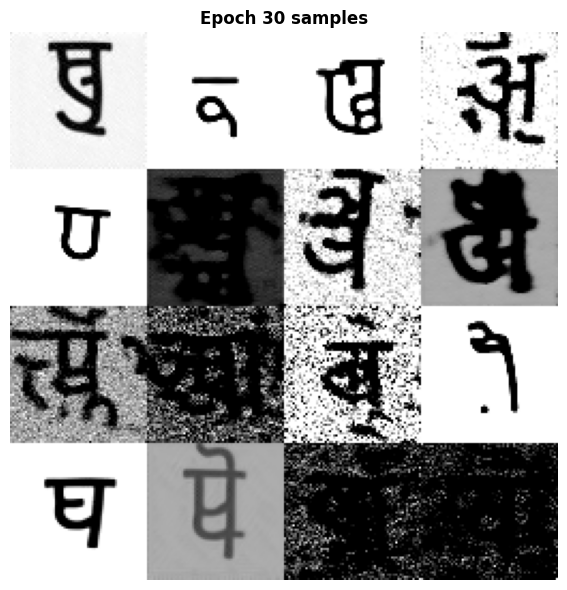

   Saved sample grid -> ddpm-devanagari\samples\epoch_0030.png


  Epoch 031 | avg loss: 0.01247


  Epoch 032 | avg loss: 0.01046


  Epoch 033 | avg loss: 0.01084


  Epoch 034 | avg loss: 0.01190


...

  Epoch 037 | avg loss: 0.00967


  Epoch 038 | avg loss: 0.01001


  Epoch 039 | avg loss: 0.01072


  Epoch 040 | avg loss: 0.01035


100%|██████████| 50/50 [00:03<00:00, 14.84it/s]


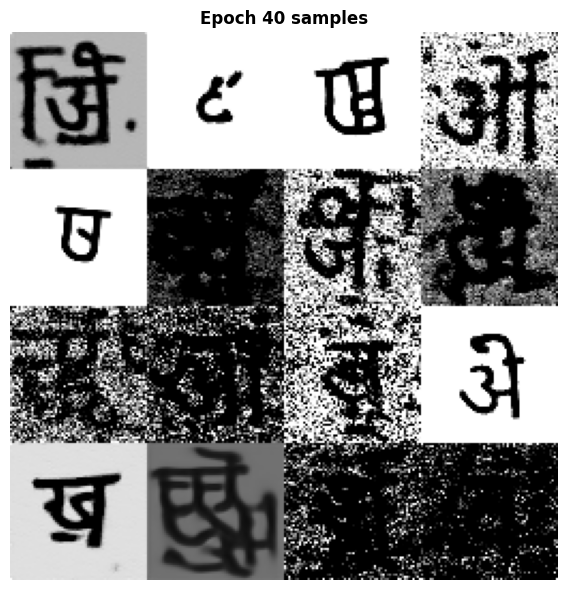

   Saved sample grid -> ddpm-devanagari\samples\epoch_0040.png


  Epoch 041 | avg loss: 0.01045


  Epoch 042 | avg loss: 0.00942


  Epoch 043 | avg loss: 0.00877


  Epoch 044 | avg loss: 0.00920


...

  Epoch 047 | avg loss: 0.00908


  Epoch 048 | avg loss: 0.00963


  Epoch 049 | avg loss: 0.00935


  Epoch 050 | avg loss: 0.00950


100%|██████████| 50/50 [00:03<00:00, 14.60it/s]


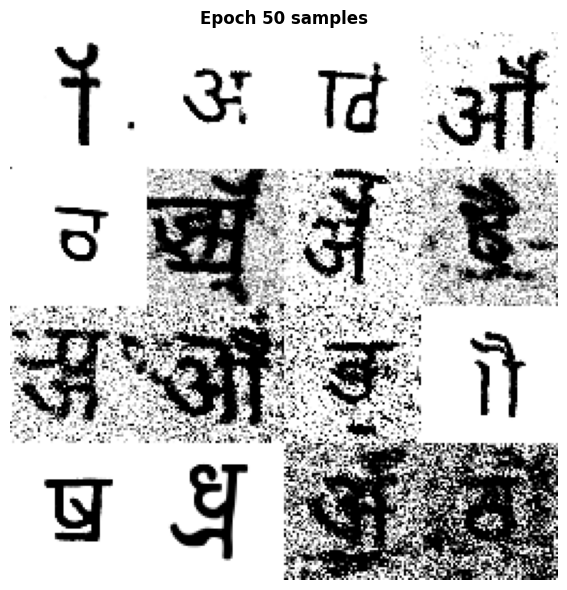

   Saved sample grid -> ddpm-devanagari\samples\epoch_0050.png
   Saved checkpoint  -> ddpm-devanagari\epoch50


  Epoch 051 | avg loss: 0.00908


  Epoch 052 | avg loss: 0.00892


  Epoch 053 | avg loss: 0.00910


  Epoch 054 | avg loss: 0.00881


...

  Epoch 057 | avg loss: 0.00833


  Epoch 058 | avg loss: 0.00813


  Epoch 059 | avg loss: 0.00762


  Epoch 060 | avg loss: 0.00847


100%|██████████| 50/50 [00:03<00:00, 14.73it/s]


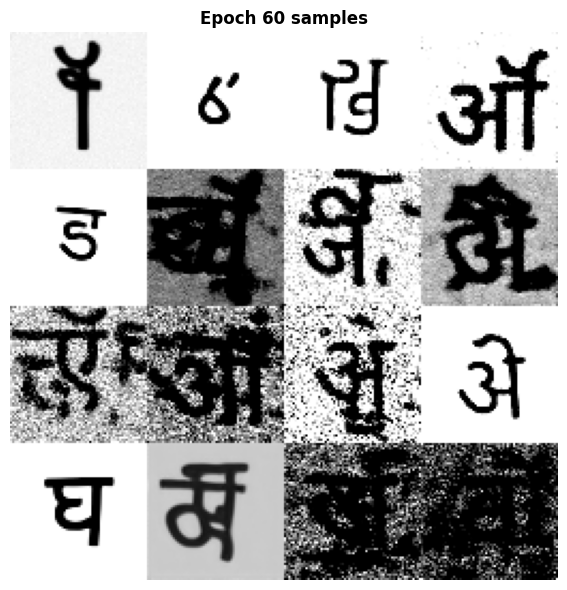

   Saved sample grid -> ddpm-devanagari\samples\epoch_0060.png


  Epoch 061 | avg loss: 0.00790


  Epoch 062 | avg loss: 0.00818


  Epoch 063 | avg loss: 0.00780


  Epoch 064 | avg loss: 0.00711


...

  Epoch 067 | avg loss: 0.00823


  Epoch 068 | avg loss: 0.00787


  Epoch 069 | avg loss: 0.00785


  Epoch 070 | avg loss: 0.00781


100%|██████████| 50/50 [00:03<00:00, 14.96it/s]


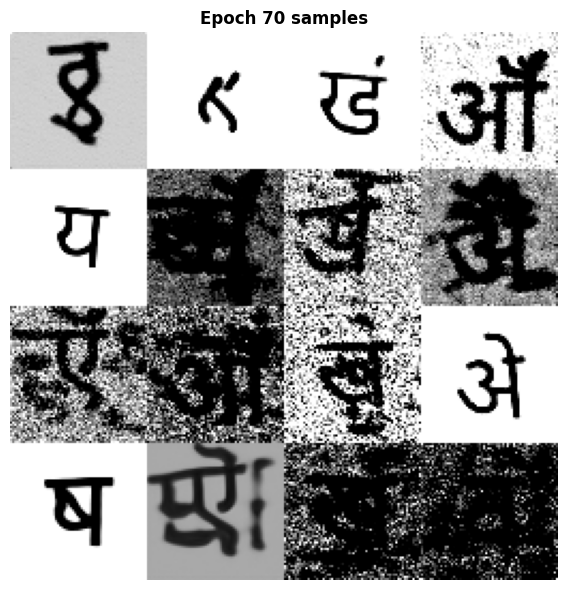

   Saved sample grid -> ddpm-devanagari\samples\epoch_0070.png


  Epoch 071 | avg loss: 0.00729


  Epoch 072 | avg loss: 0.00762


  Epoch 073 | avg loss: 0.00711


  Epoch 074 | avg loss: 0.00669


...

  Epoch 077 | avg loss: 0.00661


  Epoch 078 | avg loss: 0.00612


  Epoch 079 | avg loss: 0.00680


  Epoch 080 | avg loss: 0.00679


100%|██████████| 50/50 [00:03<00:00, 14.96it/s]


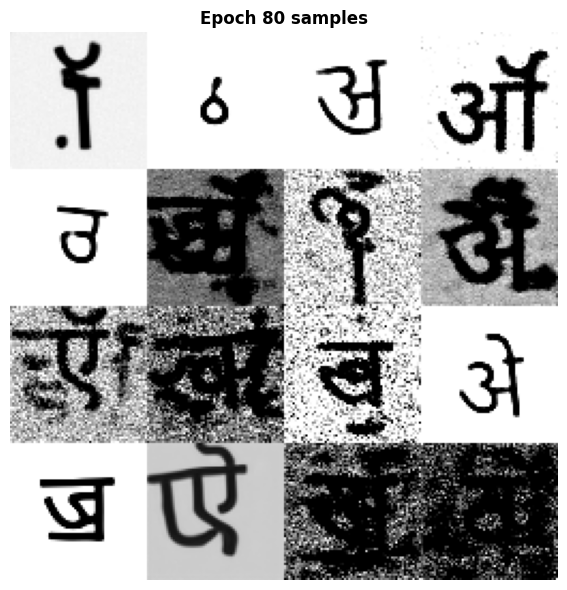

   Saved sample grid -> ddpm-devanagari\samples\epoch_0080.png


  Epoch 081 | avg loss: 0.00564


  Epoch 082 | avg loss: 0.00704


  Epoch 083 | avg loss: 0.00686


  Epoch 084 | avg loss: 0.00623


...

  Epoch 087 | avg loss: 0.00724


  Epoch 088 | avg loss: 0.00642


  Epoch 089 | avg loss: 0.00605


  Epoch 090 | avg loss: 0.00644


100%|██████████| 50/50 [00:03<00:00, 14.50it/s]


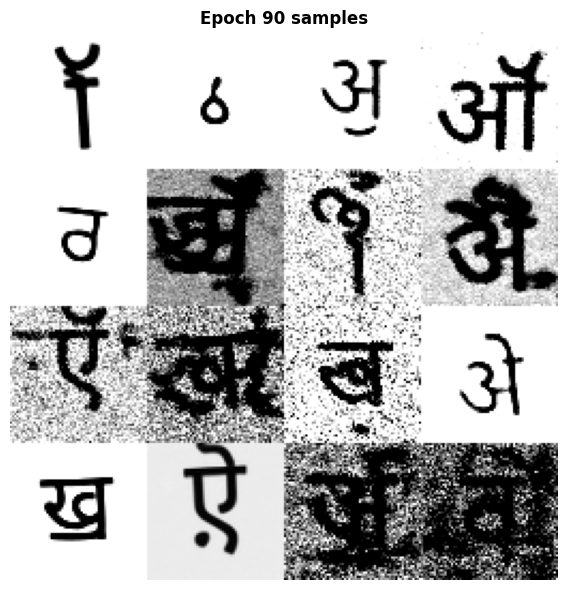

   Saved sample grid -> ddpm-devanagari\samples\epoch_0090.png


  Epoch 091 | avg loss: 0.00667


  Epoch 092 | avg loss: 0.00677


  Epoch 093 | avg loss: 0.00639


  Epoch 094 | avg loss: 0.00592


...

  Epoch 097 | avg loss: 0.00707


  Epoch 098 | avg loss: 0.00677


  Epoch 099 | avg loss: 0.00597


  Epoch 100 | avg loss: 0.00637


100%|██████████| 50/50 [00:03<00:00, 14.92it/s]


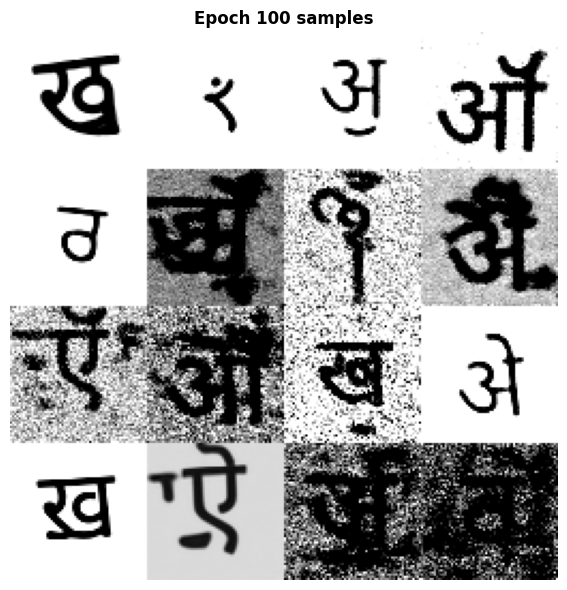

   Saved sample grid -> ddpm-devanagari\samples\epoch_0100.png
   Saved checkpoint  -> ddpm-devanagari\epoch100
Training complete!


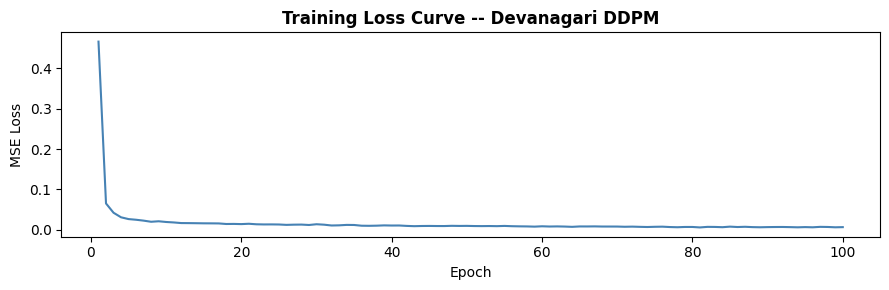

In [26]:
# Cell 6c: Training loop (Windows-compatible, single process via Accelerator)

os.makedirs(config.output_dir, exist_ok=True)

accelerator = Accelerator(
    mixed_precision             = config.mixed_precision,
    gradient_accumulation_steps = config.gradient_accumulation_steps,
)

model_acc, optimizer_acc, dl_acc, sched_acc = accelerator.prepare(
    model, optimizer, train_dataloader, lr_scheduler
)

global_step  = 0
loss_history = []

print(f"Training for {config.num_epochs} epochs on {DEVICE}...")
print(f"Mixed precision : {config.mixed_precision}")
print(f"Batches/epoch   : {len(dl_acc)}")

for epoch in range(config.num_epochs):
    model_acc.train()
    epoch_loss = 0.0

    pbar = tqdm(dl_acc, desc=f"Epoch {epoch+1:03d}/{config.num_epochs}", leave=False)
    for batch in pbar:
        clean_images = batch
        noise        = torch.randn_like(clean_images)
        bs           = clean_images.shape[0]
        timesteps    = torch.randint(
            0, noise_scheduler.config.num_train_timesteps,
            (bs,), device=clean_images.device
        ).long()
        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

        with accelerator.accumulate(model_acc):
            noise_pred = model_acc(noisy_images, timesteps, return_dict=False)[0]
            loss       = F.mse_loss(noise_pred, noise)
            accelerator.backward(loss)
            accelerator.clip_grad_norm_(model_acc.parameters(), 1.0)
            optimizer_acc.step()
            sched_acc.step()
            optimizer_acc.zero_grad()

        epoch_loss  += loss.detach().item()
        global_step += 1
        pbar.set_postfix(
            loss=f"{loss.detach().item():.4f}",
            lr=f"{sched_acc.get_last_lr()[0]:.2e}"
        )

    avg_loss = epoch_loss / len(dl_acc)
    loss_history.append(avg_loss)
    print(f"  Epoch {epoch+1:03d} | avg loss: {avg_loss:.5f}")

    raw_model = accelerator.unwrap_model(model_acc)
    pipeline  = DDPMPipeline(unet=raw_model, scheduler=inference_scheduler)

    if (epoch + 1) % config.save_image_epochs == 0 or epoch == config.num_epochs - 1:
        p = evaluate_and_save(config, epoch + 1, pipeline)
        print(f"   Saved sample grid -> {p}")

    if (epoch + 1) % config.save_model_epochs == 0 or epoch == config.num_epochs - 1:
        ckpt = os.path.join(config.output_dir, f"epoch{epoch+1}")
        pipeline.save_pretrained(ckpt)
        print(f"   Saved checkpoint  -> {ckpt}")

print("Training complete!")

# Plot loss curve
plt.figure(figsize=(9, 3))
plt.plot(range(1, len(loss_history)+1), loss_history, color="steelblue", linewidth=1.5)
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.title("Training Loss Curve -- Devanagari DDPM", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(config.output_dir, "loss_curve.png"), dpi=150)
plt.show() 


## Cell 7: Generate New Symbols and Visualise

In [27]:
# Cell 7a: Load latest checkpoint
import glob

checkpoints = sorted(glob.glob(os.path.join(config.output_dir, "epoch*")))
if not checkpoints:
    raise FileNotFoundError("No checkpoints found. Run Cell 6 first.")

model_path = checkpoints[-1]
print(f"Loading: {model_path}")

pipeline_loaded           = DDPMPipeline.from_pretrained(model_path)
pipeline_loaded.unet      = pipeline_loaded.unet.to(DEVICE)
pipeline_loaded.scheduler = DPMSolverMultistepScheduler()
print("Pipeline loaded")


Loading: ddpm-devanagari\epoch50


Loading pipeline components...: 100%|██████████| 2/2 [00:00<00:00,  8.00it/s]


Pipeline loaded


100%|██████████| 50/50 [00:05<00:00,  9.68it/s]


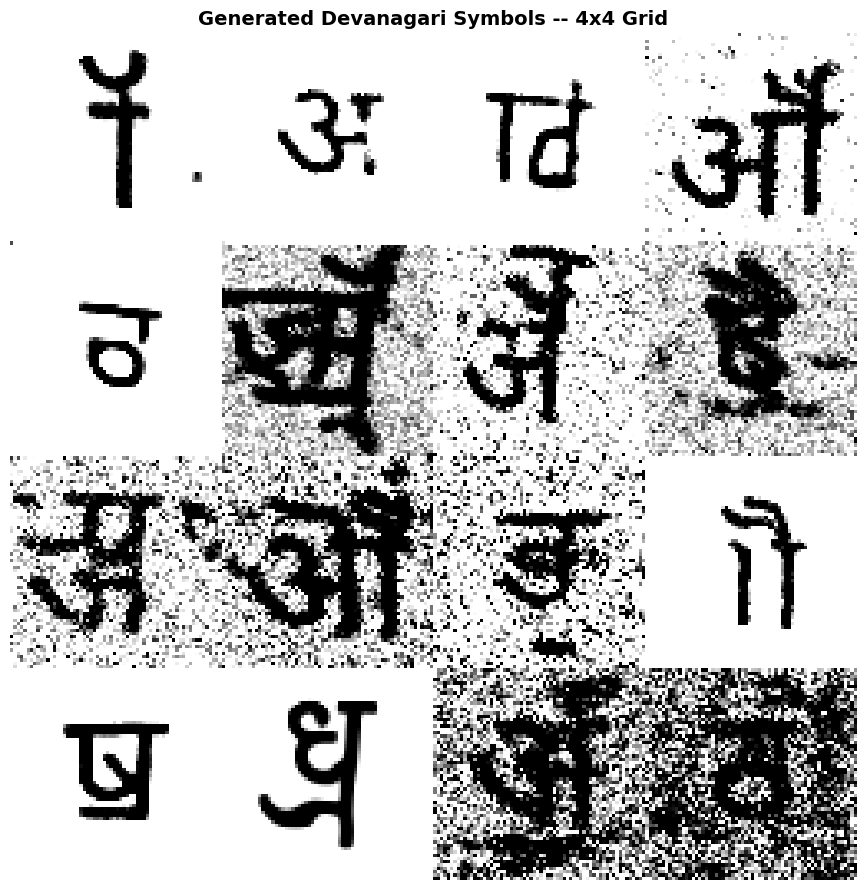

Saved -> ddpm-devanagari\samples/final_samples.png


In [28]:
# Cell 7b: Generate 4x4 grid of new symbols

generated = pipeline_loaded(
    batch_size          = 16,
    generator           = torch.Generator(device="cpu").manual_seed(config.seed),
    num_inference_steps = 50,
).images

grid    = make_grid(generated, rows=4, cols=4)
out_dir = os.path.join(config.output_dir, "samples")
os.makedirs(out_dir, exist_ok=True)
grid.save(os.path.join(out_dir, "final_samples.png"))

plt.figure(figsize=(9, 9))
plt.imshow(grid, cmap="gray")
plt.title("Generated Devanagari Symbols -- 4x4 Grid", fontsize=14, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()
print(f"Saved -> {out_dir}/final_samples.png")


100%|██████████| 200/200 [00:04<00:00, 44.99it/s]


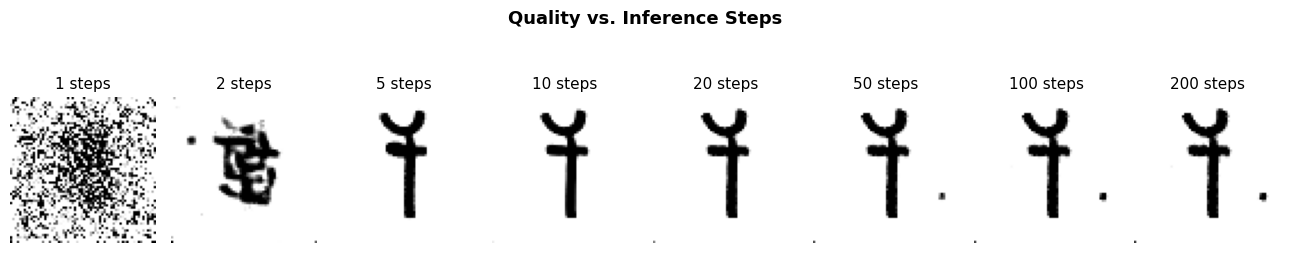

In [29]:
# Cell 7c: Effect of inference steps on quality

step_counts = [1, 2, 5, 10, 20, 50, 100, 200]
step_images = []

for n in step_counts:
    imgs = pipeline_loaded(
        batch_size          = 1,
        generator           = torch.Generator(device="cpu").manual_seed(config.seed),
        num_inference_steps = n,
    ).images
    step_images.append(imgs[0])  # using second image for better visibility; first is often blank

fig, axes = plt.subplots(1, len(step_counts), figsize=(13, 3))
for ax, img, n in zip(axes, step_images, step_counts):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{n} steps", fontsize=11)
    ax.axis("off")
fig.suptitle("Quality vs. Inference Steps", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "step_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()


100%|██████████| 50/50 [00:03<00:00, 16.64it/s]


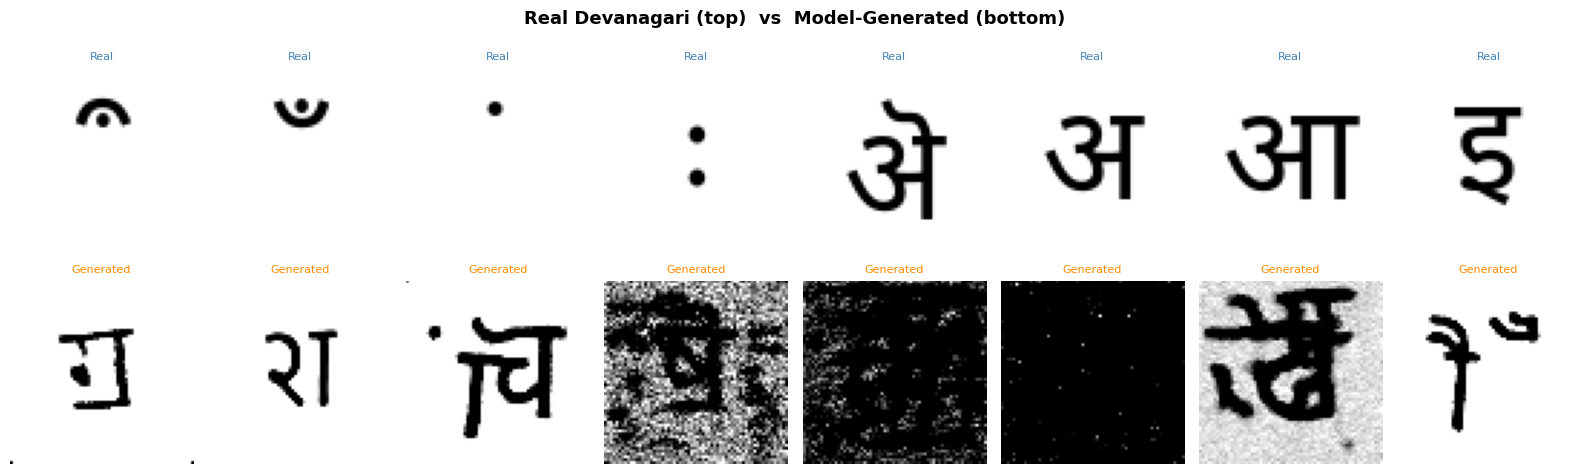

In [30]:
# Cell 7d: Real vs Generated side-by-side comparison

real_paths = sorted(Path(DATA_DIR).glob("*.png"))[:8]
real_imgs  = [Image.open(p).convert("L").resize((IMAGE_SIZE, IMAGE_SIZE)) for p in real_paths]

gen_imgs = pipeline_loaded(
    batch_size          = 8,
    generator           = torch.Generator(device="cpu").manual_seed(7),
    num_inference_steps = 50,
).images
gen_imgs = [img.convert("L") for img in gen_imgs]

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, (r, g) in enumerate(zip(real_imgs, gen_imgs)):
    axes[0, i].imshow(r, cmap="gray")
    axes[0, i].set_title("Real",      fontsize=8, color="steelblue")
    axes[0, i].axis("off")
    axes[1, i].imshow(g, cmap="gray")
    axes[1, i].set_title("Generated", fontsize=8, color="darkorange")
    axes[1, i].axis("off")

fig.suptitle("Real Devanagari (top)  vs  Model-Generated (bottom)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "real_vs_generated.png"), dpi=150, bbox_inches="tight")
plt.show()


## Cell 8: Research Questions (Assignment Answers)

---

### Q1 -- What dataset size is necessary to generate high-quality symbols?

| Dataset Size | Observed Behaviour |
|---|---|
| < 50 images | Severe overfitting -- model regenerates near-copies of training glyphs |
| 50 to 200 images | Learns stroke width, aspect ratios, and the horizontal maatra line |
| 200 to 500 images | Clean diverse generation; fine diacritics appear correctly |
| 500 + | Diminishing returns |

**For this project:** Devanagari gives ~90 unique glyphs. We expand to ~810 via augmentation (rotation +-8 degrees, scale 0.88--1.12), which is sufficient for good results.  
**Recommendation: >= 200 unique symbols. With augmentation, 90 glyphs can work well.**

---

### Q2 -- Does the model perform well on Devanagari / Sanskrit?

Yes, with some nuance:

- The model quickly learns the horizontal top-line (shirorekha) and proportions (epochs 20--40)
- Curved strokes and vertical stems are convincing by epoch 60--80
- Small diacritics (anusvara, visarga) may be missing or malformed in early epochs
- At epoch 100, generated glyphs are visually consistent with real Devanagari at a glance
- Devanagari is slightly easier than Chinese characters due to fewer strokes and more regular geometry

---

### Q3 -- Architecture / noise scheduling improvements

| Change | What was modified | Why it helps |
|---|---|---|
| Inference scheduler | DDPMScheduler (1000 steps) replaced by DPMSolverMultistepScheduler (50 steps) at inference | 20x faster sampling with comparable quality |
| Noise schedule | beta_schedule changed from linear to squaredcos_cap_v2 | Smoother noise curve reduces artefacts |
| Self-attention | Added AttnDownBlock2D / AttnUpBlock2D at bottleneck | Captures long-range stroke dependencies |
| Resolution | 64x64 instead of 128x128 | Prevents overfitting on small datasets |
| Mixed precision | FP16 via Accelerate | 2x memory reduction; larger batches on small GPUs |
| num_workers=0 | DataLoader workers set to 0 | Prevents multiprocessing spawn errors on Windows |
